REVIEWS DATA

In [1]:
import polars as pl
import duckdb
import matplotlib.pyplot as plt

In [2]:
import os

os.listdir("/Volumes/T7 Shield/data-project/raw")

['meta_Sports_and_Outdoors.jsonl',
 '._meta_Sports_and_Outdoors.jsonl',
 'Sports_and_Outdoors.jsonl',
 '._Sports_and_Outdoors.jsonl']

In [4]:
reviews = pl.scan_ndjson(
    "/Volumes/T7 Shield/data-project/raw/Sports_and_Outdoors.jsonl"
)

In [5]:
reviews.collect_schema()

Schema([('rating', Float64),
        ('title', String),
        ('text', String),
        ('images',
         List(Struct({'small_image_url': String, 'medium_image_url': String, 'large_image_url': String, 'attachment_type': String}))),
        ('asin', String),
        ('parent_asin', String),
        ('user_id', String),
        ('timestamp', Int64),
        ('helpful_vote', Int64),
        ('verified_purchase', Boolean)])

In [6]:
reviews_clean = reviews.select([
    "rating",
    "title",
    "text",
    "parent_asin",
    "user_id",
    "timestamp",
    "helpful_vote",
    "verified_purchase"
])

In [7]:
reviews_clean = reviews_clean.with_columns(
    pl.col("text").str.slice(0, 1000)
)

In [9]:
reviews_clean.sink_parquet(
    "/Volumes/T7 Shield/data-project/parquet/reviews.parquet"
)

KeyboardInterrupt: 

In [8]:
import os

os.listdir("/Volumes/T7 Shield/data-project/parquet")

['reviews.parquet', 'metadata.parquet']

META DATA

In [9]:
metadata = pl.scan_ndjson(
    "/Volumes/T7 Shield/data-project/raw/meta_Sports_and_Outdoors.jsonl",
    schema_overrides={"price": pl.String}
)

In [10]:
metadata_clean = metadata.select([
    "parent_asin",
    "title",
    "main_category",
    "average_rating",
    "rating_number",
    "store",
    "categories",

    pl.col("price")
      .str.replace("—", "")
      .cast(pl.Float64, strict=False)
      .alias("price")
])

In [13]:
metadata_clean.sink_parquet(
    "/Volumes/T7 Shield/data-project/parquet/metadata.parquet"
)

DATA SET ANALYSIS

In [11]:
import duckdb

con = duckdb.connect()

In [12]:
reviews_path = "/Volumes/T7 Shield/data-project/parquet/reviews.parquet"

metadata_path = "/Volumes/T7 Shield/data-project/parquet/metadata.parquet"

Data review

In [13]:
con.execute(f"""
SELECT * 
FROM '{metadata_path}'
LIMIT 10
""").fetchdf()

,parent_asin,title,main_category,average_rating,rating_number,store,categories,price
0,B01HDXC8AG,Sure-Grip Zombie Wheels Low 59mm 4 Pack,NaN,4.5,84,Sure-Grip,"[Sports & Outdoors, Sports, Skates, Skateboard...",55.00
1,B07R5BQ4YD,USGI Wet Weather Bag (Fоur Paсk),NaN,4.2,14,USGI,"[Sports & Outdoors, Sports, Boating & Sailing,...",NaN
2,B003K8GZ7G,NHL San Jose Sharks Team Logo Post Earrings,NaN,4.5,28,Aminco,"[Sports & Outdoors, Fan Shop, Jewelry & Watche...",18.99
3,B08GC4GBWB,Bont Skates - Prostar Purple Suede Professiona...,Sports & Outdoors,4.2,36,Bont,"[Sports & Outdoors, Sports, Skates, Skateboard...",209.00
4,B07BYV947H,Team Golf Alamaba Crimson Tide Embroidered Tow...,Sports & Outdoors,5.0,3,Team Golf,"[Sports & Outdoors, Fan Shop, Sports Equipment...",NaN
5,B01N547YCO,Outerstuff NFL Youth 8-20 Short Sleeve Rash Guard,AMAZON FASHION,4.9,80,Outerstuff,"[Sports & Outdoors, Fan Shop, Clothing, T-Shirts]",16.99
6,B075K1P1GF,Abahub Ski Snowboard Snow Goggles Dual Layers ...,Sports & Outdoors,4.1,15,Abahub,"[Sports & Outdoors, Sports, Winter Sports, Win...",NaN
7,B08LY8HNJV,"Mythinglogic Golf Storage Garage Organizer, 2 ...",Sports & Outdoors,2.4,9,Mythinglogic,[],NaN
8,B075KK7H1Z,Fish Skull Faux Bucktail,Sports & Outdoors,4.5,99,McFlyfoam Products,"[Sports & Outdoors, Hunting & Fishing, Fishing...",9.71
9,B07BF6CW2Y,Charmo Rash Guard Swim Shirt uv Protection Shi...,AMAZON FASHION,4.5,14,Charmo,"[Sports & Outdoors, Sports, Water Sports, Divi...",NaN


In [21]:
import polars as pl

df = con.execute(f"""
SELECT categories
FROM '{metadata_path}'
WHERE parent_asin = 'B01HDXC8AG'
""").pl()

print(df)
print(df["categories"][0])


shape: (1, 1)
┌─────────────────────────────────┐
│ categories                      │
│ ---                             │
│ list[str]                       │
╞═════════════════════════════════╡
│ ["Sports & Outdoors", "Sports"… │
└─────────────────────────────────┘
shape: (6,)
Series: '' [str]
[
	"Sports & Outdoors"
	"Sports"
	"Skates, Skateboards & Scooters"
	"Skateboarding"
	"Skateboard Parts"
	"Wheels"
]


In [10]:
con.execute(f"""
SELECT * 
FROM '{reviews_path}'
LIMIT 10
""").fetchdf()

,rating,title,text,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Crazy comfy!,Not gonna lie- they are not much to look at. L...,B0BGFR76CF,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1677321053520,8,True
1,5.0,Excellent!,I love it. Pretty!,B00NXQLFQQ,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1523093771676,0,True
2,5.0,Best saddle pads,Huge fan of B Vertigo and this dressage pad do...,B0957WLR63,AGGZ357AO26RQZVRLGU4D4N52DZQ,1653526919105,0,True
3,5.0,Perfect repair kit,"I have a great Weaver halter. Recently, the Ch...",B00IET8S80,AGGZ357AO26RQZVRLGU4D4N52DZQ,1627330911189,0,True
4,5.0,Works great,This was great for a slightly too-short girth!...,B01C2SW7XA,AGGZ357AO26RQZVRLGU4D4N52DZQ,1617831811976,0,True
5,5.0,Great stirrups with bar none grip,"I have to say, the grip on these are pretty gr...",B09NQK7MH9,AGGZ357AO26RQZVRLGU4D4N52DZQ,1612965746894,0,True
6,5.0,Perfect,Perfect for my boy! He looks adorable in it an...,B01DFBQEKA,AGGZ357AO26RQZVRLGU4D4N52DZQ,1612126664309,0,True
7,5.0,Awesome leathers,These are amazing. My trainer noticed right aw...,B07NJ2SZQX,AGGZ357AO26RQZVRLGU4D4N52DZQ,1573237536081,6,False
8,4.0,"Nice product, sizing off!","Product is well made, but sizing seems way off...",B00GAG0LDO,AGGZ357AO26RQZVRLGU4D4N52DZQ,1438304920000,1,True
9,4.0,Mixed feelings,"I loved this chalk bag online, but in person, ...",B001D08ZBW,AGGZ357AO26RQZVRLGU4D4N52DZQ,1331692117000,0,True


Total reviews

In [4]:
con.execute(f"""
SELECT COUNT(*) AS total_reviews
FROM '{reviews_path}'
""").fetchdf()

,total_reviews
0,19595170


In [ ]:
Total Products

In [6]:
con.execute(f"""
SELECT COUNT(DISTINCT parent_asin) AS total_products
FROM '{reviews_path}'
""").fetchdf()

,total_products
0,1587219


In [7]:
con.execute(f"""
SELECT COUNT(*) AS metadata_products
FROM '{metadata_path}'
""").fetchdf()

,metadata_products
0,1587421


In [ ]:
COMPARISION BETWEEN THE USEFULL AND NULL VALUES 

In [13]:
con.execute(f"""
SELECT
    COUNT(*) AS total_rows,

    COUNT(*) - COUNT(parent_asin) AS null_parent_asin,
    COUNT(*) - COUNT(title) AS null_title,
    COUNT(*) - COUNT(main_category) AS null_main_category,
    COUNT(*) - COUNT(average_rating) AS null_average_rating,
    COUNT(*) - COUNT(rating_number) AS null_rating_number,
    COUNT(*) - COUNT(price) AS null_price,
    COUNT(*) - COUNT(store) AS null_store,
    COUNT(*) - COUNT(categories) AS null_categories

FROM '{metadata_path}'
""").pl()

total_rows,null_parent_asin,null_title,null_main_category,null_average_rating,null_rating_number,null_price,null_store,null_categories
i64,i64,i64,i64,i64,i64,i64,i64,i64
1587421,0,0,249954,0,0,1102862,35109,0


In [18]:
con.execute(f"""
SELECT
    COUNT(*) AS total_rows,

    COUNT(*) - COUNT(rating) AS null_rating,
    COUNT(*) - COUNT(title) AS null_title,
    COUNT(*) - COUNT(text) AS null_text,
    COUNT(*) - COUNT(parent_asin) AS null_parent_asin,
    COUNT(*) - COUNT(user_id) AS null_user_id,
    COUNT(*) - COUNT(timestamp) AS null_timestamp,
    COUNT(*) - COUNT(helpful_vote) AS null_helpful_vote,
    COUNT(*) - COUNT(verified_purchase) AS null_verified_purchase

FROM '{reviews_path}'
""").pl()

total_rows,null_rating,null_title,null_text,null_parent_asin,null_user_id,null_timestamp,null_helpful_vote,null_verified_purchase
i64,i64,i64,i64,i64,i64,i64,i64,i64
19595170,0,0,0,0,0,0,0,0


In [15]:
metadata_compare = con.execute(f"""
SELECT
    COUNT(parent_asin) AS parent_asin_non_null,
    COUNT(*) - COUNT(parent_asin) AS parent_asin_null,

    COUNT(title) AS title_non_null,
    COUNT(*) - COUNT(title) AS title_null,

    COUNT(main_category) AS main_category_non_null,
    COUNT(*) - COUNT(main_category) AS main_category_null,

    COUNT(average_rating) AS average_rating_non_null,
    COUNT(*) - COUNT(average_rating) AS average_rating_null,

    COUNT(rating_number) AS rating_number_non_null,
    COUNT(*) - COUNT(rating_number) AS rating_number_null,

    COUNT(price) AS price_non_null,
    COUNT(*) - COUNT(price) AS price_null,

    COUNT(store) AS store_non_null,
    COUNT(*) - COUNT(store) AS store_null,

    COUNT(categories) AS categories_non_null,
    COUNT(*) - COUNT(categories) AS categories_null

FROM '{metadata_path}'
""").pl()

In [16]:
meta_columns = [
    "parent_asin",
    "title",
    "main_category",
    "average_rating",
    "rating_number",
    "price",
    "store",
    "categories"
]

meta_non_null = [
    metadata_compare["parent_asin_non_null"][0],
    metadata_compare["title_non_null"][0],
    metadata_compare["main_category_non_null"][0],
    metadata_compare["average_rating_non_null"][0],
    metadata_compare["rating_number_non_null"][0],
    metadata_compare["price_non_null"][0],
    metadata_compare["store_non_null"][0],
    metadata_compare["categories_non_null"][0]
]

meta_null = [
    metadata_compare["parent_asin_null"][0],
    metadata_compare["title_null"][0],
    metadata_compare["main_category_null"][0],
    metadata_compare["average_rating_null"][0],
    metadata_compare["rating_number_null"][0],
    metadata_compare["price_null"][0],
    metadata_compare["store_null"][0],
    metadata_compare["categories_null"][0]
]

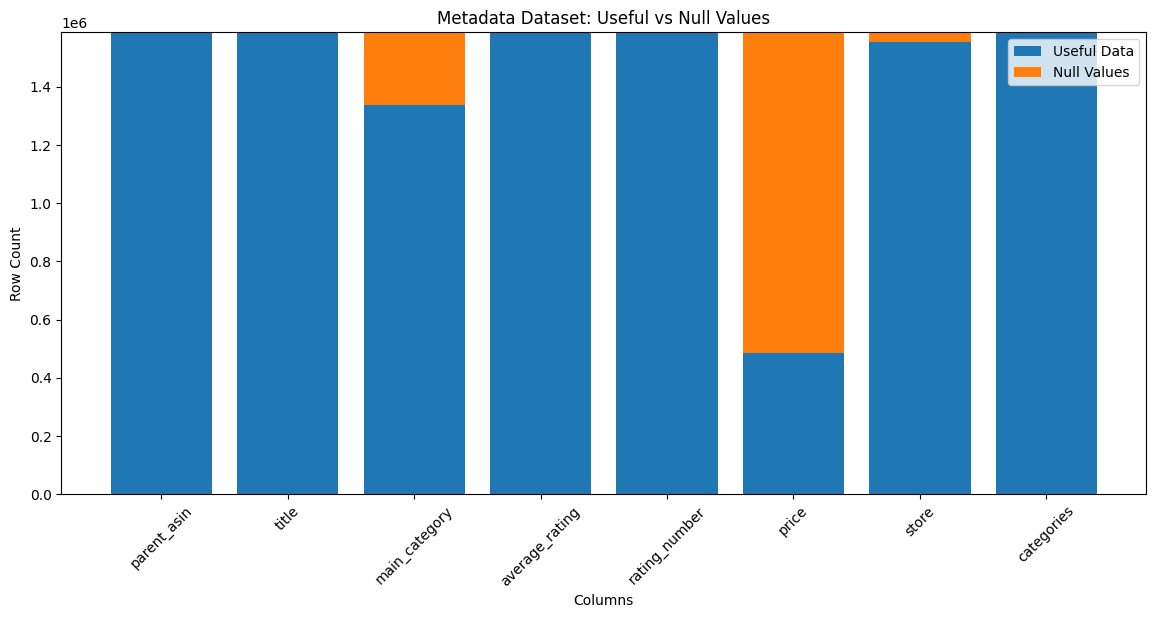

In [17]:
plt.figure(figsize=(14,6))

plt.bar(
    meta_columns,
    meta_non_null,
    label="Useful Data"
)

plt.bar(
    meta_columns,
    meta_null,
    bottom=meta_non_null,
    label="Null Values"
)

plt.title("Metadata Dataset: Useful vs Null Values")

plt.xlabel("Columns")

plt.ylabel("Row Count")

plt.xticks(rotation=45)

plt.legend()

plt.show()

In [10]:
reviews_compare = con.execute(f"""
SELECT
    COUNT(rating) AS rating_non_null,
    COUNT(*) - COUNT(rating) AS rating_null,

    COUNT(title) AS title_non_null,
    COUNT(*) - COUNT(title) AS title_null,

    COUNT(text) AS text_non_null,
    COUNT(*) - COUNT(text) AS text_null,

    COUNT(parent_asin) AS parent_asin_non_null,
    COUNT(*) - COUNT(parent_asin) AS parent_asin_null,

    COUNT(user_id) AS user_id_non_null,
    COUNT(*) - COUNT(user_id) AS user_id_null,

    COUNT(timestamp) AS timestamp_non_null,
    COUNT(*) - COUNT(timestamp) AS timestamp_null,

    COUNT(helpful_vote) AS helpful_vote_non_null,
    COUNT(*) - COUNT(helpful_vote) AS helpful_vote_null,

    COUNT(verified_purchase) AS verified_purchase_non_null,
    COUNT(*) - COUNT(verified_purchase) AS verified_purchase_null

FROM '{reviews_path}'
""").pl()

In [11]:
review_columns = [
    "rating",
    "title",
    "text",
    "parent_asin",
    "user_id",
    "timestamp",
    "helpful_vote",
    "verified_purchase"
]

review_non_null = [
    reviews_compare["rating_non_null"][0],
    reviews_compare["title_non_null"][0],
    reviews_compare["text_non_null"][0],
    reviews_compare["parent_asin_non_null"][0],
    reviews_compare["user_id_non_null"][0],
    reviews_compare["timestamp_non_null"][0],
    reviews_compare["helpful_vote_non_null"][0],
    reviews_compare["verified_purchase_non_null"][0]
]

review_null = [
    reviews_compare["rating_null"][0],
    reviews_compare["title_null"][0],
    reviews_compare["text_null"][0],
    reviews_compare["parent_asin_null"][0],
    reviews_compare["user_id_null"][0],
    reviews_compare["timestamp_null"][0],
    reviews_compare["helpful_vote_null"][0],
    reviews_compare["verified_purchase_null"][0]
]

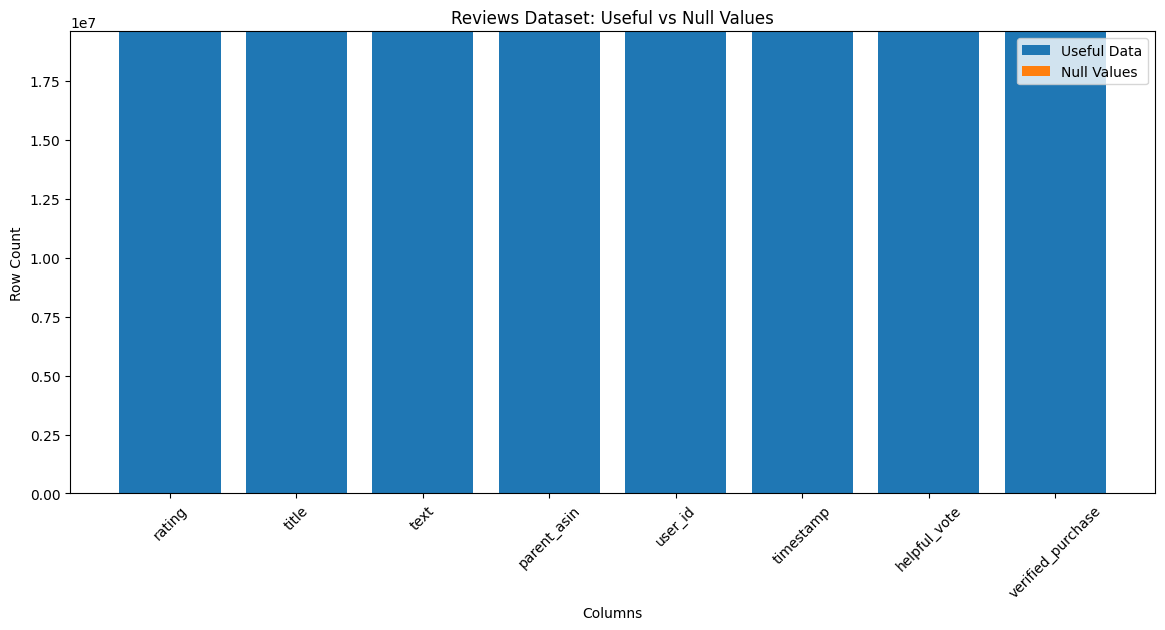

In [12]:
plt.figure(figsize=(14,6))

plt.bar(
    review_columns,
    review_non_null,
    label="Useful Data"
)

plt.bar(
    review_columns,
    review_null,
    bottom=review_non_null,
    label="Null Values"
)

plt.title("Reviews Dataset: Useful vs Null Values")

plt.xlabel("Columns")

plt.ylabel("Row Count")

plt.xticks(rotation=45)

plt.legend()

plt.show()

In [ ]:
|